Loading outputs/dem.npz...
DEM Grid Shape : 2,627 rows x 3,243 cols (8,519,361 cells)
Elevation Range: 267.00 m to 298.00 m (Mean: 283.81 m)
Saved 4-panel visual plot to: outputs/dem_visualization.png


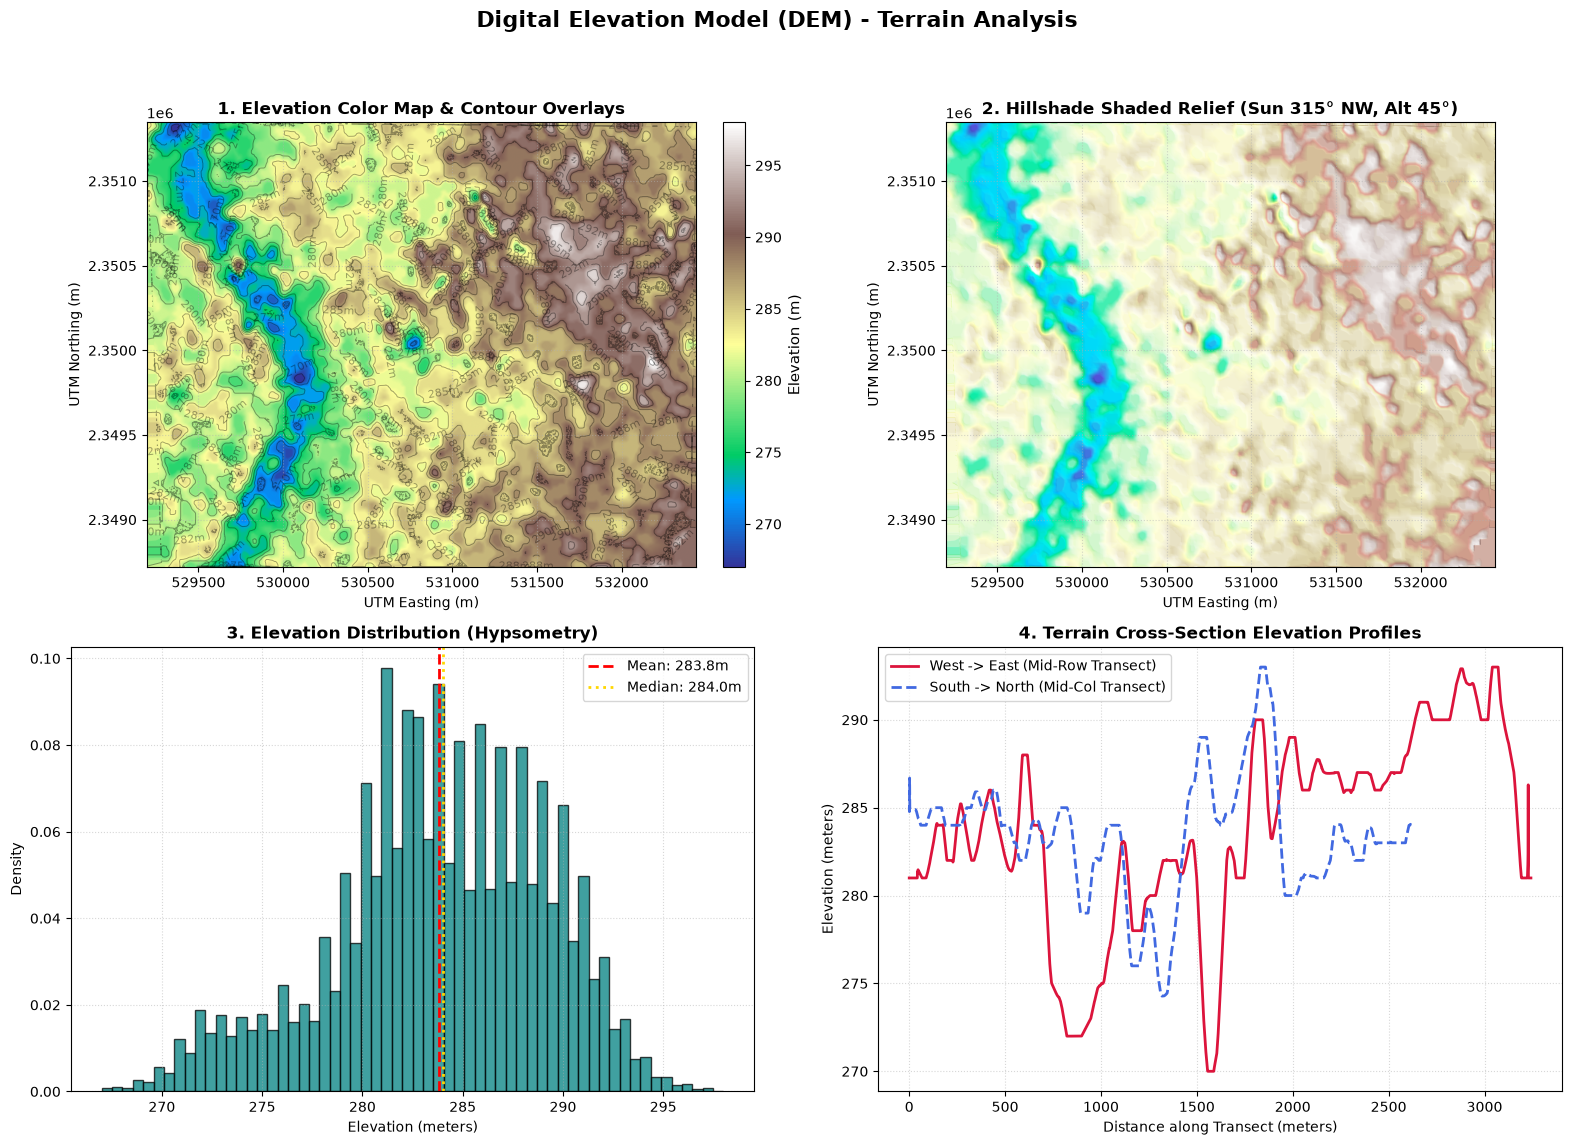


Generating 3D Surface View...
Saved 3D surface plot to: outputs/dem_3d_surface.png


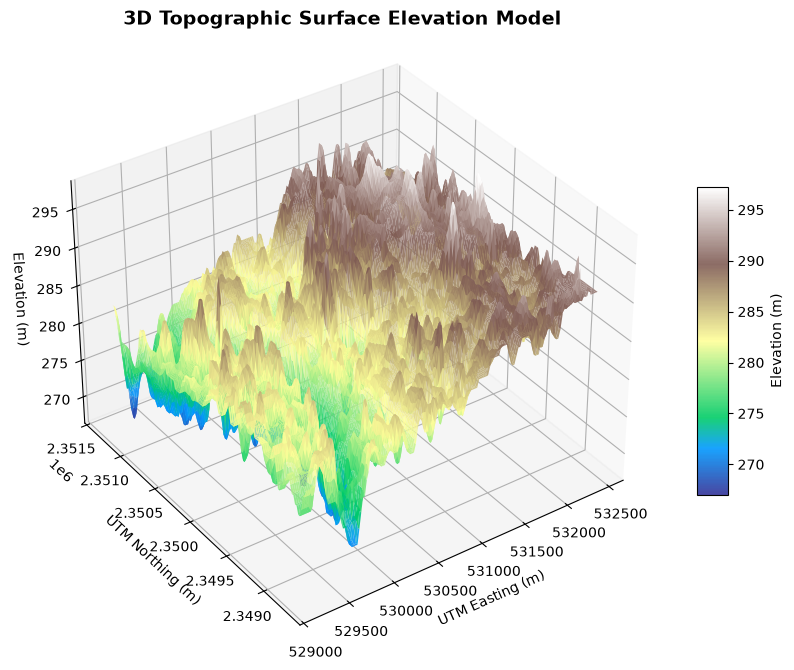

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource

# --------------------------------------------------
# 1. Load DEM File
# --------------------------------------------------
DEM_FILE = "outputs/dem.npz"
OUTPUT_IMAGE = "outputs/dem_visualization.png"

if not os.path.exists(DEM_FILE):
    raise FileNotFoundError(f"Cannot find {DEM_FILE}. Please run Step 3 (build_dem.py) first.")

print(f"Loading {DEM_FILE}...")
data = np.load(DEM_FILE)
dem = data["dem"]
grid_x = data["grid_x"]
grid_y = data["grid_y"]
resolution = float(data["resolution"])

min_x, max_x = grid_x.min(), grid_x.max()
min_y, max_y = grid_y.min(), grid_y.max()
extent = [min_x, max_x, min_y, max_y]

print(f"DEM Grid Shape : {dem.shape[0]:,} rows x {dem.shape[1]:,} cols ({dem.size:,} cells)")
print(f"Elevation Range: {dem.min():.2f} m to {dem.max():.2f} m (Mean: {dem.mean():.2f} m)")

# --------------------------------------------------
# 2. Compute Analytical Hillshade (Sun Azimuth=315°, Altitude=45°)
# --------------------------------------------------
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem, vert_exag=2.0, dx=resolution, dy=resolution)

# --------------------------------------------------
# 3. Create 4-Panel Comprehensive Visualization Figure
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Digital Elevation Model (DEM) - Terrain Analysis", fontsize=16, fontweight="bold")

# Panel 1: 2D Elevation Map with Contour Lines
ax1 = axes[0, 0]
im1 = ax1.imshow(dem, origin="lower", extent=extent, cmap="terrain")
contours = ax1.contour(grid_x, grid_y, dem, levels=12, colors="black", alpha=0.35, linewidths=0.7)
ax1.clabel(contours, inline=True, fontsize=8, fmt="%.0fm")
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label("Elevation (m)", fontsize=11)
ax1.set_title("1. Elevation Color Map & Contour Overlays", fontsize=12, fontweight="bold")
ax1.set_xlabel("UTM Easting (m)")
ax1.set_ylabel("UTM Northing (m)")
ax1.grid(True, linestyle=":", alpha=0.5)

# Panel 2: Hillshade 3D Relief (Sun Shaded)
ax2 = axes[0, 1]
ax2.imshow(hillshade, origin="lower", extent=extent, cmap="gray")
# Blend elevation color on top of hillshade
rgb_blend = ls.shade(dem, cmap=plt.cm.terrain, blend_mode="overlay", vert_exag=2.0, dx=resolution, dy=resolution)
im2 = ax2.imshow(rgb_blend, origin="lower", extent=extent)
ax2.set_title("2. Hillshade Shaded Relief (Sun 315° NW, Alt 45°)", fontsize=12, fontweight="bold")
ax2.set_xlabel("UTM Easting (m)")
ax2.set_ylabel("UTM Northing (m)")
ax2.grid(True, linestyle=":", alpha=0.5)

# Panel 3: Elevation Frequency Distribution (Histogram)
ax3 = axes[1, 0]
ax3.hist(dem.ravel(), bins=60, color="teal", edgecolor="black", alpha=0.75, density=True)
ax3.axvline(dem.mean(), color="red", linestyle="--", linewidth=2, label=f"Mean: {dem.mean():.1f}m")
ax3.axvline(np.median(dem), color="gold", linestyle=":", linewidth=2, label=f"Median: {np.median(dem):.1f}m")
ax3.set_title("3. Elevation Distribution (Hypsometry)", fontsize=12, fontweight="bold")
ax3.set_xlabel("Elevation (meters)")
ax3.set_ylabel("Density")
ax3.legend(frameon=True)
ax3.grid(True, linestyle=":", alpha=0.5)

# Panel 4: Cross-Section Profiles (West-East & South-North Transects)
ax4 = axes[1, 1]
mid_row = dem.shape[0] // 2
mid_col = dem.shape[1] // 2

# Profile 1: West to East along the center row
we_x = grid_x[mid_row, :] - min_x
we_elev = dem[mid_row, :]
ax4.plot(we_x, we_elev, color="crimson", label="West -> East (Mid-Row Transect)", linewidth=2.0)

# Profile 2: South to North along the center column
sn_y = grid_y[:, mid_col] - min_y
sn_elev = dem[:, mid_col]
ax4.plot(sn_y, sn_elev, color="royalblue", label="South -> North (Mid-Col Transect)", linewidth=2.0, linestyle="--")

ax4.set_title("4. Terrain Cross-Section Elevation Profiles", fontsize=12, fontweight="bold")
ax4.set_xlabel("Distance along Transect (meters)")
ax4.set_ylabel("Elevation (meters)")
ax4.legend(frameon=True)
ax4.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches="tight")
print(f"Saved 4-panel visual plot to: {OUTPUT_IMAGE}")
plt.show()

# --------------------------------------------------
# 4. Optional: 3D Surface Mesh Plot
# --------------------------------------------------
print("\nGenerating 3D Surface View...")
fig3d = plt.figure(figsize=(12, 8))
ax3d = fig3d.add_subplot(111, projection="3d")

# Downsample slightly (every 20th cell) for smooth 3D rendering
stride = 20
x_sub = grid_x[::stride, ::stride]
y_sub = grid_y[::stride, ::stride]
z_sub = dem[::stride, ::stride]

surf = ax3d.plot_surface(
    x_sub, y_sub, z_sub,
    cmap="terrain",
    rstride=1, cstride=1,
    linewidth=0,
    antialiased=True,
    alpha=0.9
)
fig3d.colorbar(surf, ax=ax3d, shrink=0.5, aspect=10, label="Elevation (m)")
ax3d.set_title("3D Topographic Surface Elevation Model", fontsize=14, fontweight="bold")
ax3d.set_xlabel("UTM Easting (m)")
ax3d.set_ylabel("UTM Northing (m)")
ax3d.set_zlabel("Elevation (m)")
ax3d.view_init(elev=35, azim=-125)

plt.savefig("outputs/dem_3d_surface.png", dpi=200, bbox_inches="tight")
print("Saved 3D surface plot to: outputs/dem_3d_surface.png")
plt.show()


Loading outputs/terrain_analysis.npz...

Classification Summary:
  • Flat (0° - 3°)   : 4,233,335 cells (49.7%)
  • Gentle (3° - 8°) : 3,715,939 cells (43.6%)
  • Steep (> 8°)     : 570,087 cells (6.7%)
Saved visualization to: outputs/terrain_classification.png


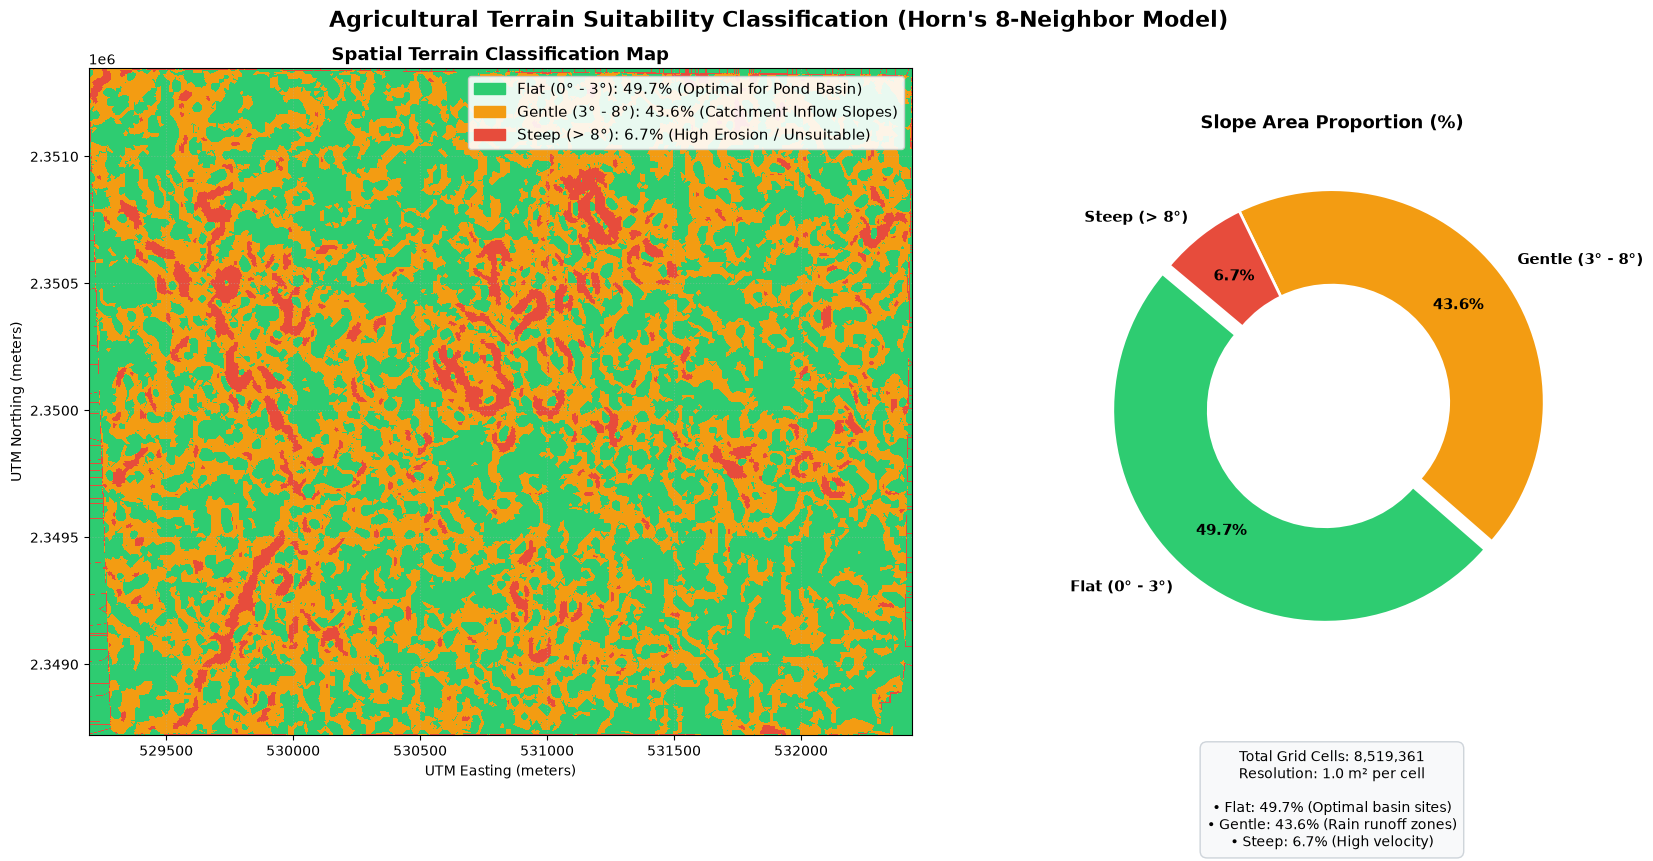

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# --------------------------------------------------
# 1. Load Terrain Analysis Data
# --------------------------------------------------
INPUT_FILE = "outputs/terrain_analysis.npz"
OUTPUT_IMAGE = "outputs/terrain_classification.png"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Cannot find {INPUT_FILE}. Please run calculate_slope.py first.")

print(f"Loading {INPUT_FILE}...")
data = np.load(INPUT_FILE)
slope_degrees = data["slope_degrees"]
grid_x = data["grid_x"]
grid_y = data["grid_y"]
total_cells = slope_degrees.size

# --------------------------------------------------
# 2. Categorize Terrain by Slope
# --------------------------------------------------
# 0 = Flat (0° - 3°), 1 = Gentle (3° - 8°), 2 = Steep (> 8°)
classified = np.zeros_like(slope_degrees, dtype=np.uint8)
classified[(slope_degrees > 3.0) & (slope_degrees <= 8.0)] = 1
classified[slope_degrees > 8.0] = 2

flat_count = np.count_nonzero(classified == 0)
gentle_count = np.count_nonzero(classified == 1)
steep_count = np.count_nonzero(classified == 2)

flat_pct = (flat_count / total_cells) * 100.0
gentle_pct = (gentle_count / total_cells) * 100.0
steep_pct = (steep_count / total_cells) * 100.0

print("\nClassification Summary:")
print(f"  • Flat (0° - 3°)   : {flat_count:,} cells ({flat_pct:.1f}%)")
print(f"  • Gentle (3° - 8°) : {gentle_count:,} cells ({gentle_pct:.1f}%)")
print(f"  • Steep (> 8°)     : {steep_count:,} cells ({steep_pct:.1f}%)")

# --------------------------------------------------
# 3. Create Custom Colormap for Discrete Classes
# --------------------------------------------------
# Colors: Flat = Forest Green, Gentle = Gold/Amber, Steep = Crimson Red
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
cmap = ListedColormap(colors)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

# --------------------------------------------------
# 4. Generate 2-Panel Figure
# --------------------------------------------------
fig, (ax_map, ax_chart) = plt.subplots(
    1, 2, figsize=(18, 8),
    gridspec_kw={"width_ratios": [2.2, 1.0]}
)
fig.suptitle("Agricultural Terrain Suitability Classification (Horn's 8-Neighbor Model)", fontsize=16, fontweight="bold")

# Panel 1: Classified 2D Spatial Map
min_x, max_x = grid_x.min(), grid_x.max()
min_y, max_y = grid_y.min(), grid_y.max()
extent = [min_x, max_x, min_y, max_y]

im = ax_map.imshow(classified, origin="lower", extent=extent, cmap=cmap, norm=norm, interpolation="nearest")

# Custom Legend
patches = [
    mpatches.Patch(color=colors[0], label=f"Flat (0° - 3°): {flat_pct:.1f}% (Optimal for Pond Basin)"),
    mpatches.Patch(color=colors[1], label=f"Gentle (3° - 8°): {gentle_pct:.1f}% (Catchment Inflow Slopes)"),
    mpatches.Patch(color=colors[2], label=f"Steep (> 8°): {steep_pct:.1f}% (High Erosion / Unsuitable)")
]
ax_map.legend(handles=patches, loc="upper right", framealpha=0.9, fontsize=11)
ax_map.set_title("Spatial Terrain Classification Map", fontsize=13, fontweight="bold")
ax_map.set_xlabel("UTM Easting (meters)")
ax_map.set_ylabel("UTM Northing (meters)")
ax_map.grid(True, linestyle=":", alpha=0.4)

# Panel 2: Distribution Donut Chart
labels = ["Flat (0° - 3°)", "Gentle (3° - 8°)", "Steep (> 8°)"]
sizes = [flat_count, gentle_count, steep_count]
explode = (0.05, 0.0, 0.0)  # Explode Flat slice

wedges, texts, autotexts = ax_chart.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11, fontweight="bold")
)

# Style text inside slices
for autotext in autotexts:
    autotext.set_color("black")

ax_chart.set_title("Slope Area Proportion (%)", fontsize=13, fontweight="bold")

# Add summary text box below chart
info_text = (
    f"Total Grid Cells: {total_cells:,}\n"
    f"Resolution: 1.0 m² per cell\n\n"
    f"• Flat: {flat_pct:.1f}% (Optimal basin sites)\n"
    f"• Gentle: {gentle_pct:.1f}% (Rain runoff zones)\n"
    f"• Steep: {steep_pct:.1f}% (High velocity)"
)
ax_chart.text(
    0.5, -0.25, info_text,
    transform=ax_chart.transAxes,
    ha="center", va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", edgecolor="#ced4da")
)

plt.tight_layout()
plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches="tight")
print(f"Saved visualization to: {OUTPUT_IMAGE}")
plt.show()


Loading outputs/flow_direction.npz...
Simulating downhill rainwater streamlines...
Traced 476 continuous flow paths down the terrain.

Saved flow visualization image to: outputs/water_flow_lines.png


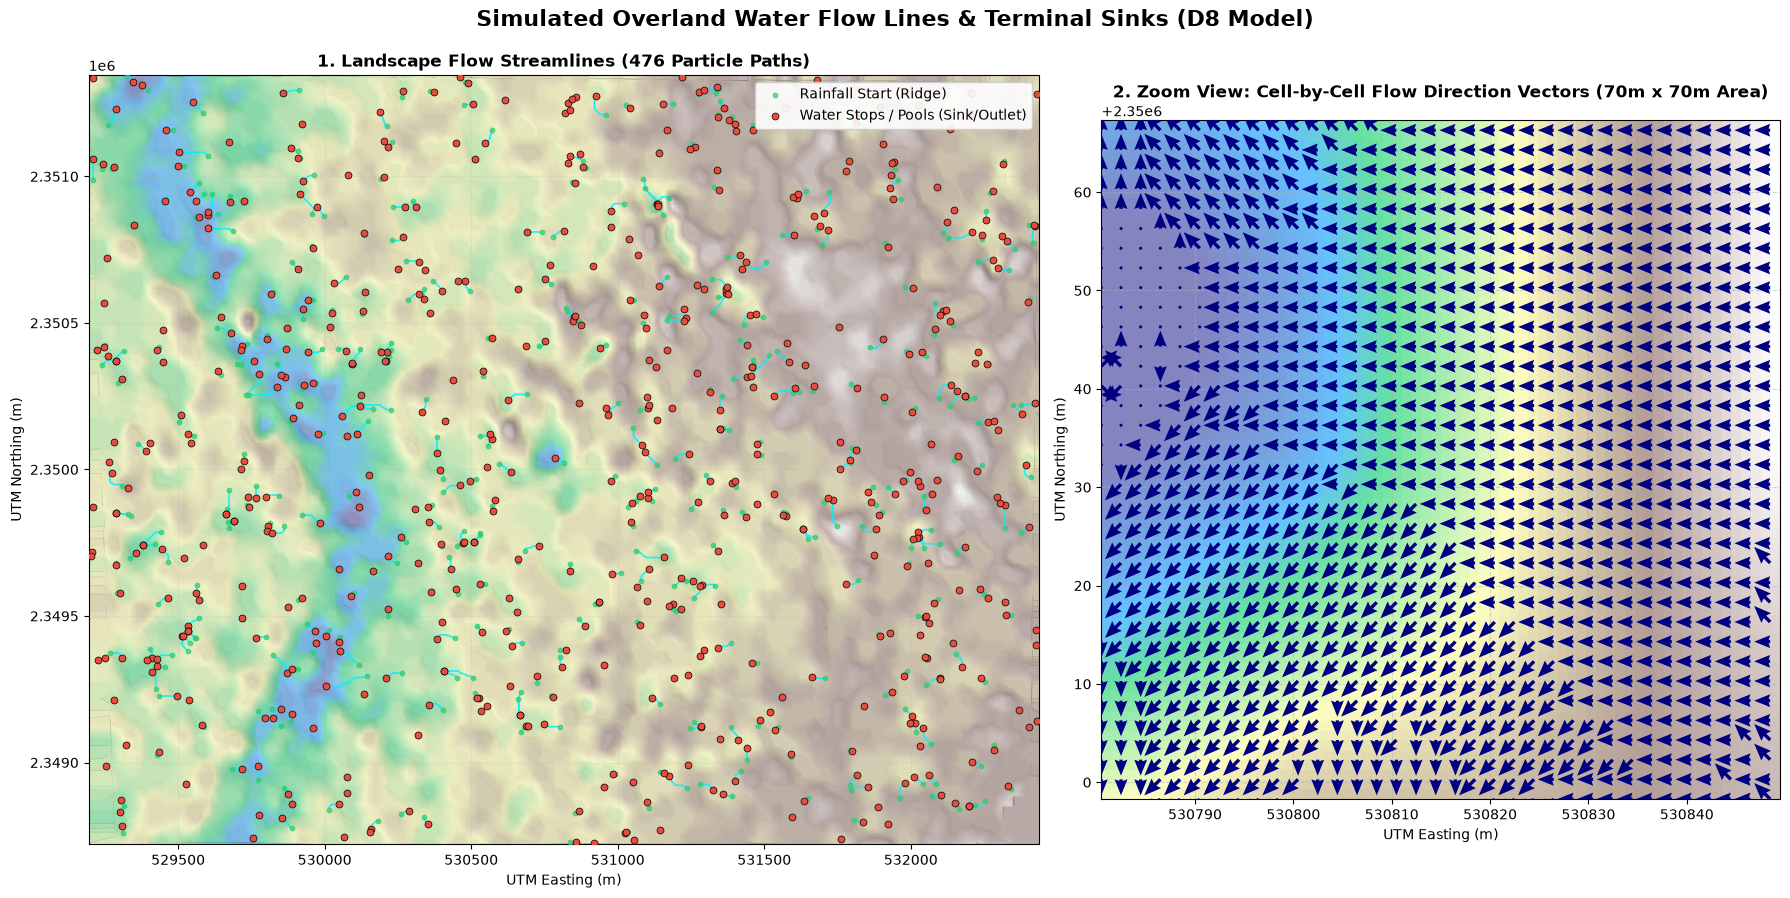

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from matplotlib.collections import LineCollection

# --------------------------------------------------
# 1. Load Flow Direction & DEM Data
# --------------------------------------------------
INPUT_FILE = "outputs/flow_direction.npz"
OUTPUT_IMAGE = "outputs/water_flow_lines.png"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Cannot find {INPUT_FILE}. Please run calculate_flow_direction.py first.")

print(f"Loading {INPUT_FILE}...")
data = np.load(INPUT_FILE)
dem = data["dem"]
flow_direction = data["flow_direction"]
grid_x = data["grid_x"]
grid_y = data["grid_y"]
resolution = float(data["resolution"])
rows, cols = dem.shape

# 8 Direction offsets: NW, N, NE, W, E, SW, S, SE
DIRECTIONS = [
    (-1, -1), (-1,  0), (-1,  1),
    ( 0, -1),           ( 0,  1),
    ( 1, -1), ( 1,  0), ( 1,  1)
]

# --------------------------------------------------
# 2. Simulate Raindrop Streamline Particle Tracing
# --------------------------------------------------
print("Simulating downhill rainwater streamlines...")
NUM_SEEDS = 600  # Number of random raindrop streamlines to trace
MAX_STEPS = 1000  # Maximum length of a flow line

np.random.seed(42)
seed_rows = np.random.randint(5, rows - 5, size=NUM_SEEDS)
seed_cols = np.random.randint(5, cols - 5, size=NUM_SEEDS)

streamlines = []
start_points = []
stop_points = []

for sr, sc in zip(seed_rows, seed_cols):
    curr_r, curr_c = sr, sc
    path_x = [grid_x[curr_r, curr_c]]
    path_y = [grid_y[curr_r, curr_c]]
    
    start_points.append((grid_x[curr_r, curr_c], grid_y[curr_r, curr_c]))
    
    visited = set([(curr_r, curr_c)])
    
    for _ in range(MAX_STEPS):
        d = flow_direction[curr_r, curr_c]
        if d == -1:  # Reached a sink or map edge (Water stops here)
            break
        
        dr, dc = DIRECTIONS[d]
        next_r, next_c = curr_r + dr, curr_c + dc
        
        if not (0 <= next_r < rows and 0 <= next_c < cols):
            break  # Exited map boundary
            
        if (next_r, next_c) in visited:
            break  # Loop / flat depression reached
            
        visited.add((next_r, next_c))
        curr_r, curr_c = next_r, next_c
        path_x.append(grid_x[curr_r, curr_c])
        path_y.append(grid_y[curr_r, curr_c])
        
    stop_points.append((path_x[-1], path_y[-1]))
    if len(path_x) > 1:
        streamlines.append(np.column_stack([path_x, path_y]))

print(f"Traced {len(streamlines)} continuous flow paths down the terrain.")

# --------------------------------------------------
# 3. Create High-Fidelity Visualization
# --------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9), gridspec_kw={"width_ratios": [1.4, 1.0]})
fig.suptitle("Simulated Overland Water Flow Lines & Terminal Sinks (D8 Model)", fontsize=16, fontweight="bold")

min_x, max_x = grid_x.min(), grid_x.max()
min_y, max_y = grid_y.min(), grid_y.max()
extent = [min_x, max_x, min_y, max_y]

# Create background hillshade relief
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem, vert_exag=2.0, dx=resolution, dy=resolution)

# --- Panel 1: Full Landscape Flow Streamlines ---
ax1.imshow(hillshade, origin="lower", extent=extent, cmap="gray", alpha=0.7)
im_dem = ax1.imshow(dem, origin="lower", extent=extent, cmap="terrain", alpha=0.45)

# Plot streamlines as glowing cyan lines
line_segments = LineCollection(streamlines, colors="#00f0ff", linewidths=1.2, alpha=0.85, zorder=3)
ax1.add_collection(line_segments)

# Plot Start Points (Green) & Stop/Sink Points (Red)
start_x, start_y = zip(*start_points)
stop_x, stop_y = zip(*stop_points)

ax1.scatter(start_x, start_y, color="#2ecc71", s=10, label="Rainfall Start (Ridge)", zorder=4, alpha=0.7)
ax1.scatter(stop_x, stop_y, color="#e74c3c", s=25, edgecolors="black", linewidth=0.5, label="Water Stops / Pools (Sink/Outlet)", zorder=5)

ax1.legend(loc="upper right", framealpha=0.9, fontsize=10)
ax1.set_title(f"1. Landscape Flow Streamlines ({len(streamlines)} Particle Paths)", fontsize=12, fontweight="bold")
ax1.set_xlabel("UTM Easting (m)")
ax1.set_ylabel("UTM Northing (m)")
ax1.grid(True, linestyle=":", alpha=0.4)

# --- Panel 2: Zoomed-in Vector Quiver Arrows (Flow Direction) ---
# Pick a high-gradient 100m x 100m window in the center
center_r, center_c = rows // 2, cols // 2
crop_size = 35  # 35x35 meter sub-region

r_slice = slice(center_r - crop_size, center_r + crop_size)
c_slice = slice(center_c - crop_size, center_c + crop_size)

sub_dem = dem[r_slice, c_slice]
sub_dir = flow_direction[r_slice, c_slice]
sub_x = grid_x[r_slice, c_slice]
sub_y = grid_y[r_slice, c_slice]

# Vector components for each D8 code (dx, dy)
# Code order: NW, N, NE, W, E, SW, S, SE, Sink
VEC_U = np.array([-1.0,  0.0, 1.0, -1.0, 1.0, -1.0,  0.0, 1.0, 0.0]) / np.sqrt(2)
VEC_V = np.array([ 1.0,  1.0, 1.0,  0.0, 0.0, -1.0, -1.0, -1.0, 0.0]) / np.sqrt(2)

valid_mask = sub_dir >= 0
u = np.zeros_like(sub_dir, dtype=float)
v = np.zeros_like(sub_dir, dtype=float)
u[valid_mask] = VEC_U[sub_dir[valid_mask]]
v[valid_mask] = VEC_V[sub_dir[valid_mask]]

# Background for zoom view
sub_extent = [sub_x.min(), sub_x.max(), sub_y.min(), sub_y.max()]
ax2.imshow(sub_dem, origin="lower", extent=sub_extent, cmap="terrain", alpha=0.6)

# Overlay vector arrows
stride = 2  # Plot every 2nd arrow for clarity
ax2.quiver(
    sub_x[::stride, ::stride], sub_y[::stride, ::stride],
    u[::stride, ::stride], v[::stride, ::stride],
    color="navy", scale=30, width=0.005, headwidth=4, headlength=5, zorder=4
)

ax2.set_title("2. Zoom View: Cell-by-Cell Flow Direction Vectors (70m x 70m Area)", fontsize=12, fontweight="bold")
ax2.set_xlabel("UTM Easting (m)")
ax2.set_ylabel("UTM Northing (m)")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches="tight")
print(f"\nSaved flow visualization image to: {OUTPUT_IMAGE}")
plt.show()


Loading outputs/flow_accumulation.npz...
Flow Accumulation Range: 1.0 to 8,274.0 m²


ValueError: 'cyan' is not a valid value for cmap. Did you mean one of: 'ocean', 'ocean_r'?
See `matplotlib.bivar_colormaps()` and `matplotlib.multivar_colormaps()` for bivariate and multivariate colormaps

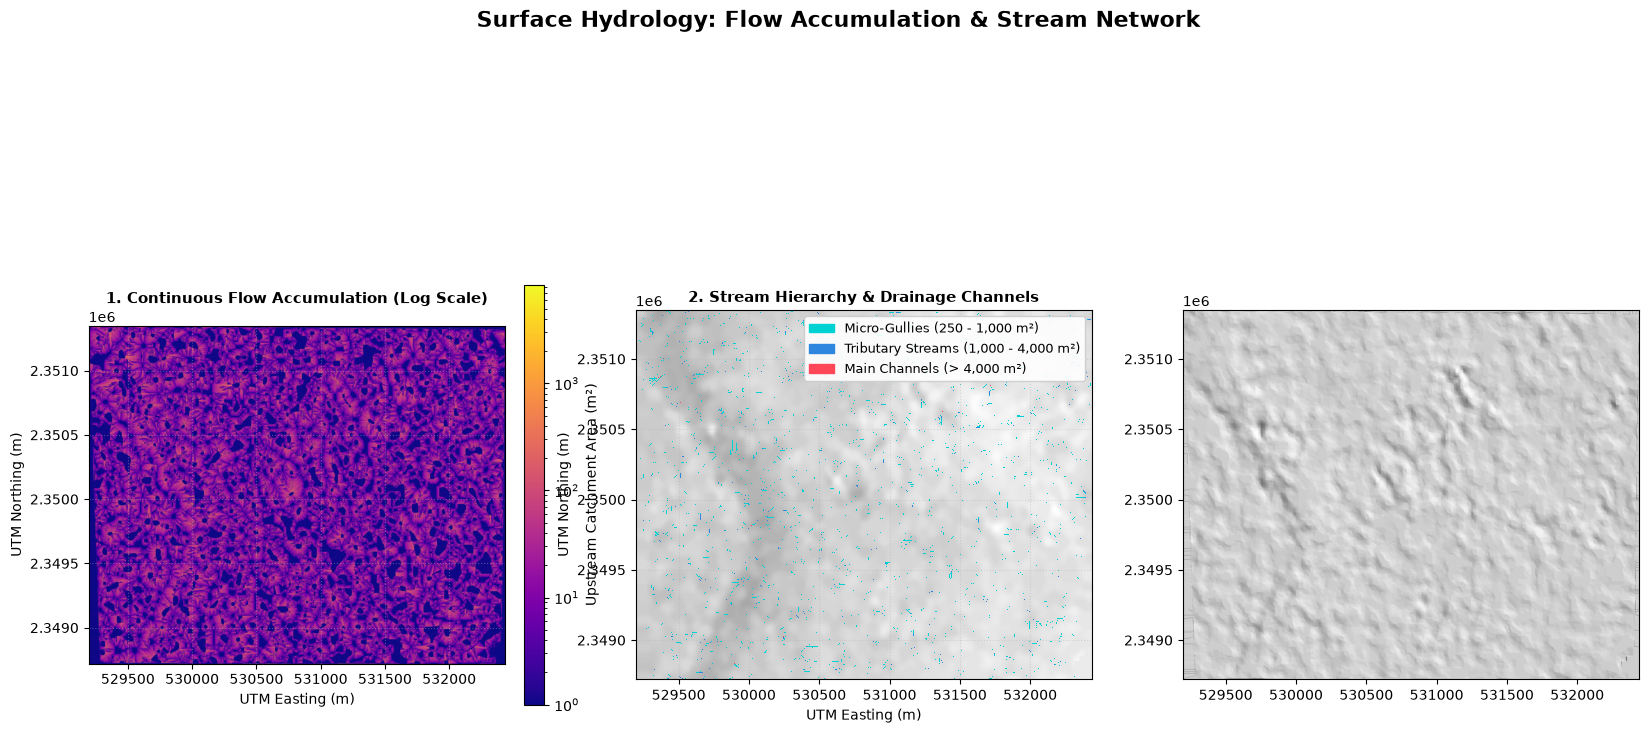

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LightSource
import matplotlib.patches as mpatches

# --------------------------------------------------
# 1. Load Flow Accumulation Data
# --------------------------------------------------
INPUT_FILE = "outputs/flow_accumulation.npz"
OUTPUT_IMAGE = "outputs/flow_accumulation_visualization.png"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Cannot find {INPUT_FILE}. Please run calculate_flow_accumulation.py first.")

print(f"Loading {INPUT_FILE}...")
data = np.load(INPUT_FILE)
dem = data["dem"]
flow_accumulation = data["flow_accumulation"]
resolution = float(data["resolution"])
grid_x = data["grid_x"]
grid_y = data["grid_y"]

min_x, max_x = grid_x.min(), grid_x.max()
min_y, max_y = grid_y.min(), grid_y.max()
extent = [min_x, max_x, min_y, max_y]

max_flow = flow_accumulation.max()
print(f"Flow Accumulation Range: {flow_accumulation.min():.1f} to {max_flow:,.1f} m²")

# --------------------------------------------------
# 2. Create Analytical Hillshade Relief
# --------------------------------------------------
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem, vert_exag=2.0, dx=resolution, dy=resolution)

# --------------------------------------------------
# 3. Stream Network Hierarchy Classification
# --------------------------------------------------
# 0 = Overland Sheetflow (< 250 m²)
# 1 = Micro-Gullies (250 - 1,000 m²)
# 2 = Tributary Streams (1,000 - 4,000 m²)
# 3 = Main Drainage Channels (> 4,000 m²)
stream_order = np.zeros_like(flow_accumulation, dtype=np.uint8)
stream_order[(flow_accumulation >= 250) & (flow_accumulation < 1000)] = 1
stream_order[(flow_accumulation >= 1000) & (flow_accumulation < 4000)] = 2
stream_order[flow_accumulation >= 4000] = 3

# --------------------------------------------------
# 4. Generate 3-Panel Comprehensive Figure
# --------------------------------------------------
fig = plt.figure(figsize=(20, 10))
fig.suptitle("Surface Hydrology: Flow Accumulation & Stream Network", fontsize=16, fontweight="bold")

# --- Panel 1: Continuous Flow Accumulation (Log Scale) ---
ax1 = plt.subplot(1, 3, 1)
im1 = ax1.imshow(
    flow_accumulation,
    origin="lower",
    extent=extent,
    cmap="plasma",
    norm=LogNorm(vmin=1.0, vmax=max_flow)
)
cbar1 = plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
cbar1.set_label("Upstream Catchment Area (m²)", fontsize=10)
ax1.set_title("1. Continuous Flow Accumulation (Log Scale)", fontsize=11, fontweight="bold")
ax1.set_xlabel("UTM Easting (m)")
ax1.set_ylabel("UTM Northing (m)")
ax1.grid(True, linestyle=":", alpha=0.4)

# --- Panel 2: Stream Hierarchy Classification ---
ax2 = plt.subplot(1, 3, 2)
# Background DEM in subtle gray
ax2.imshow(dem, origin="lower", extent=extent, cmap="gray", alpha=0.35)

# Masked layers for each stream order
gullies = np.ma.masked_where(stream_order != 1, stream_order)
tributaries = np.ma.masked_where(stream_order != 2, stream_order)
main_streams = np.ma.masked_where(stream_order != 3, stream_order)

ax2.imshow(gullies, origin="lower", extent=extent, cmap=plt.cm.colors.ListedColormap(["#00d2d3"]), interpolation="nearest")
ax2.imshow(tributaries, origin="lower", extent=extent, cmap=plt.cm.colors.ListedColormap(["#2e86de"]), interpolation="nearest")
ax2.imshow(main_streams, origin="lower", extent=extent, cmap=plt.cm.colors.ListedColormap(["#ff4757"]), interpolation="nearest")

patches = [
    mpatches.Patch(color="#00d2d3", label="Micro-Gullies (250 - 1,000 m²)"),
    mpatches.Patch(color="#2e86de", label="Tributary Streams (1,000 - 4,000 m²)"),
    mpatches.Patch(color="#ff4757", label="Main Channels (> 4,000 m²)")
]
ax2.legend(handles=patches, loc="upper right", framealpha=0.9, fontsize=9)
ax2.set_title("2. Stream Hierarchy & Drainage Channels", fontsize=11, fontweight="bold")
ax2.set_xlabel("UTM Easting (m)")
ax2.set_ylabel("UTM Northing (m)")
ax2.grid(True, linestyle=":", alpha=0.4)

# --- Panel 3: Hillshade + Active Stream Channel Overlay ---
ax3 = plt.subplot(1, 3, 3)
ax3.imshow(hillshade, origin="lower", extent=extent, cmap="gray")

# Highlight streams (> 1,000 m² accumulation) glowing in cyan/yellow
stream_mask = np.ma.masked_where(flow_accumulation < 1000, flow_accumulation)
im3 = ax3.imshow(stream_mask, origin="lower", extent=extent, cmap="cyan", norm=LogNorm(vmin=1000, vmax=max_flow), alpha=0.9)

# Mark the maximum discharge point (potential basin sink)
max_r, max_c = np.unravel_index(np.argmax(flow_accumulation), flow_accumulation.shape)
max_x_pt, max_y_pt = grid_x[max_r, max_c], grid_y[max_r, max_c]
ax3.scatter(max_x_pt, max_y_pt, color="red", s=80, edgecolors="white", linewidth=1.5, label=f"Max Outlet ({max_flow:,.0f} m²)", zorder=5)

ax3.legend(loc="upper right", framealpha=0.9, fontsize=9)
ax3.set_title("3. Topographic Valleys & Active Streams Overlay", fontsize=11, fontweight="bold")
ax3.set_xlabel("UTM Easting (m)")
ax3.set_ylabel("UTM Northing (m)")
ax3.grid(True, linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches="tight")
print(f"Saved visualization to: {OUTPUT_IMAGE}")
plt.show()


Loading outputs/flow_accumulation.npz...
Saved bright blue stream network map to: outputs/bright_blue_stream_network.png


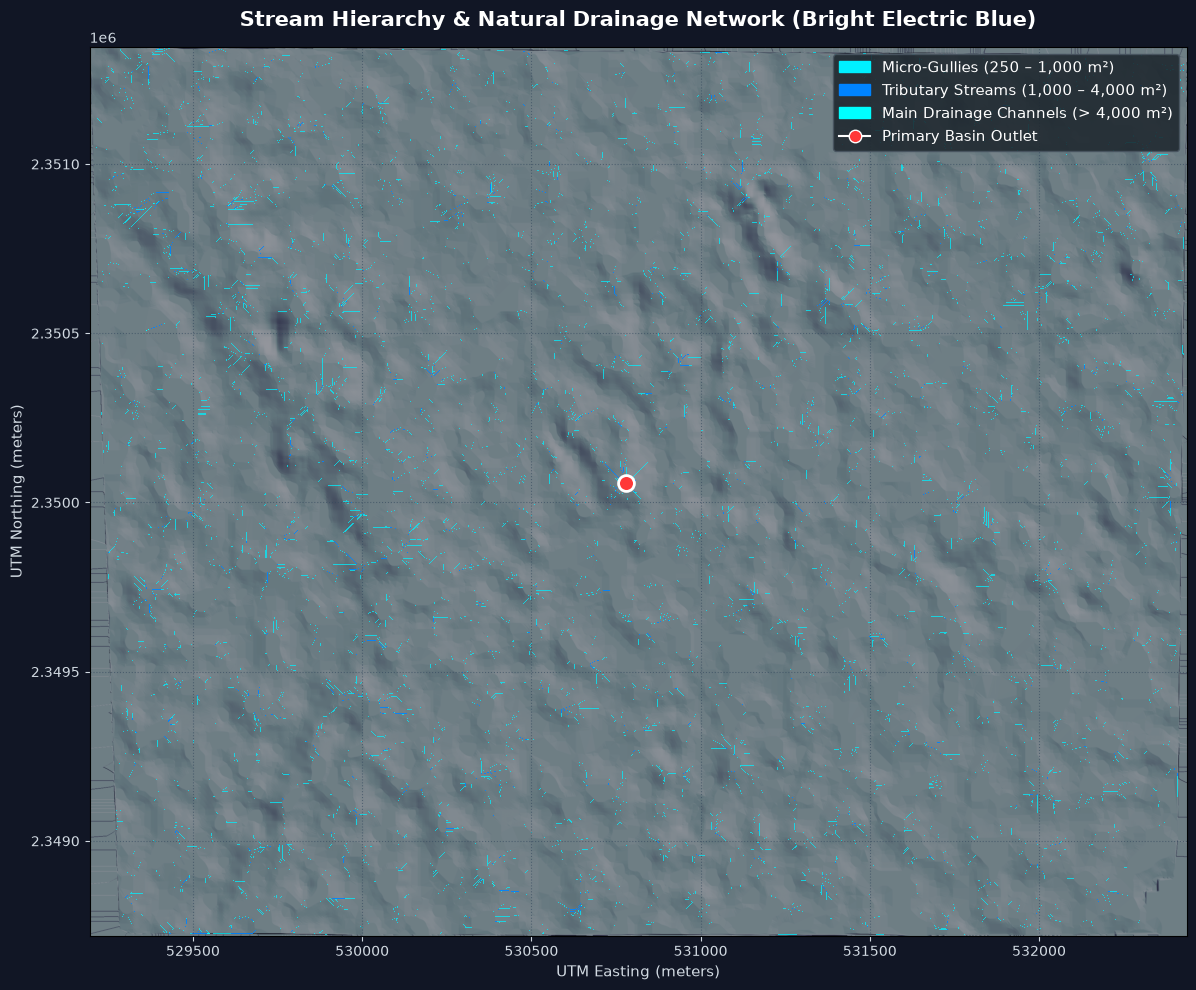

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LogNorm
import matplotlib.patches as mpatches

# --------------------------------------------------
# 1. Load Data
# --------------------------------------------------
INPUT_FILE = "outputs/flow_accumulation.npz"
OUTPUT_IMAGE = "outputs/bright_blue_stream_network.png"

if not os.path.exists(INPUT_FILE):
    raise FileNotFoundError(f"Cannot find {INPUT_FILE}. Run calculate_flow_accumulation.py first.")

print(f"Loading {INPUT_FILE}...")
data = np.load(INPUT_FILE)
dem = data["dem"]
flow_acc = data["flow_accumulation"]
resolution = float(data["resolution"])
grid_x = data["grid_x"]
grid_y = data["grid_y"]

min_x, max_x = grid_x.min(), grid_x.max()
min_y, max_y = grid_y.min(), grid_y.max()
extent = [min_x, max_x, min_y, max_y]

# --------------------------------------------------
# 2. Compute Hillshade Relief Background
# --------------------------------------------------
ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem, vert_exag=2.0, dx=resolution, dy=resolution)

# --------------------------------------------------
# 3. Create Multi-Tier Bright Blue Stream Masks
# --------------------------------------------------
# Hierarchy definitions
mask_gullies = (flow_acc >= 250) & (flow_acc < 1000)      # Micro-Gullies (Ice Aqua)
mask_tributaries = (flow_acc >= 1000) & (flow_acc < 4000) # Secondary Tributaries (Neon Blue)
mask_main = (flow_acc >= 4000)                            # Main River Arteries (Deep Electric Blue)

# --------------------------------------------------
# 4. Render High-Resolution Map
# --------------------------------------------------
plt.figure(figsize=(14, 10), facecolor="#111625")
ax = plt.gca()
ax.set_facecolor("#111625")

# Layer 1: Dark Slate Hillshade Background
ax.imshow(hillshade, origin="lower", extent=extent, cmap="bone", alpha=0.55)

# Layer 2: Micro-Gullies (Ice Aqua #00f0ff)
masked_1 = np.ma.masked_where(~mask_gullies, flow_acc)
ax.imshow(masked_1, origin="lower", extent=extent, cmap=plt.cm.colors.ListedColormap(["#00f0ff"]), alpha=0.75, interpolation="nearest")

# Layer 3: Tributary Streams (Bright Neon Blue #0084ff)
masked_2 = np.ma.masked_where(~mask_tributaries, flow_acc)
ax.imshow(masked_2, origin="lower", extent=extent, cmap=plt.cm.colors.ListedColormap(["#0084ff"]), alpha=0.90, interpolation="nearest")

# Layer 4: Main Drainage Arteries (Vibrant Electric Blue #0033ff)
masked_3 = np.ma.masked_where(~mask_main, flow_acc)
ax.imshow(masked_3, origin="lower", extent=extent, cmap=plt.cm.colors.ListedColormap(["#00ffff"]), alpha=1.0, interpolation="nearest")

# Layer 5: Mark the Primary Drainage Outlet Point
max_r, max_c = np.unravel_index(np.argmax(flow_acc), flow_acc.shape)
outlet_x, outlet_y = grid_x[max_r, max_c], grid_y[max_r, max_c]
ax.scatter(outlet_x, outlet_y, color="#ff3838", s=130, edgecolors="white", linewidth=2.0, label=f"Main Basin Outlet ({flow_acc.max():,.0f} m²)", zorder=6)

# --------------------------------------------------
# 5. Styling & Legend
# --------------------------------------------------
patches = [
    mpatches.Patch(color="#00f0ff", label="Micro-Gullies (250 – 1,000 m²)"),
    mpatches.Patch(color="#0084ff", label="Tributary Streams (1,000 – 4,000 m²)"),
    mpatches.Patch(color="#00ffff", label=f"Main Drainage Channels (> 4,000 m²)"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#ff3838", markersize=9, label="Primary Basin Outlet")
]

leg = ax.legend(handles=patches, loc="upper right", framealpha=0.88, facecolor="#1e272e", edgecolor="#485460", fontsize=11)
for text in leg.get_texts():
    text.set_color("white")

plt.title("Stream Hierarchy & Natural Drainage Network (Bright Electric Blue)", fontsize=15, fontweight="bold", color="white", pad=15)
plt.xlabel("UTM Easting (meters)", color="#d2dae2", fontsize=11)
plt.ylabel("UTM Northing (meters)", color="#d2dae2", fontsize=11)
ax.tick_params(colors="#d2dae2")
ax.grid(True, linestyle=":", color="#34495e", alpha=0.6)

plt.tight_layout()
plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches="tight", facecolor="#111625")
print(f"Saved bright blue stream network map to: {OUTPUT_IMAGE}")
plt.show()


Loading data...
Total candidate cells meeting criteria: 13,521

 TOP 5 OPTIMAL POND LOCATIONS (Min Distance: 150.0m)
[RANK #1] Score: 0.8880 | Elev: 270.0m | Slope: 2.68° | Catchment: 8,274m²
  • Lat: 21.251917, Lon: 81.296668 (UTM X=530780.5, Y=2350057.3)
  • Maps: https://www.google.com/maps?q=21.251917,81.296668
[RANK #2] Score: 0.8321 | Elev: 287.0m | Slope: 1.59° | Catchment: 7,877m²
  • Lat: 21.256956, Lon: 81.303512 (UTM X=531489.5, Y=2350616.3)
  • Maps: https://www.google.com/maps?q=21.256956,81.303512
[RANK #3] Score: 0.8079 | Elev: 269.0m | Slope: 0.44° | Catchment: 6,236m²
  • Lat: 21.246238, Lon: 81.28914 (UTM X=530000.5, Y=2349427.3)
  • Maps: https://www.google.com/maps?q=21.246238,81.289140
[RANK #4] Score: 0.7940 | Elev: 269.0m | Slope: 1.82° | Catchment: 6,696m²
  • Lat: 21.259328, Lon: 81.285329 (UTM X=529602.5, Y=2350875.3)
  • Maps: https://www.google.com/maps?q=21.259328,81.285329
[RANK #5] Score: 0.7838 | Elev: 272.0m | Slope: 1.57° | Catchment: 6,596m²
  • Lat: 

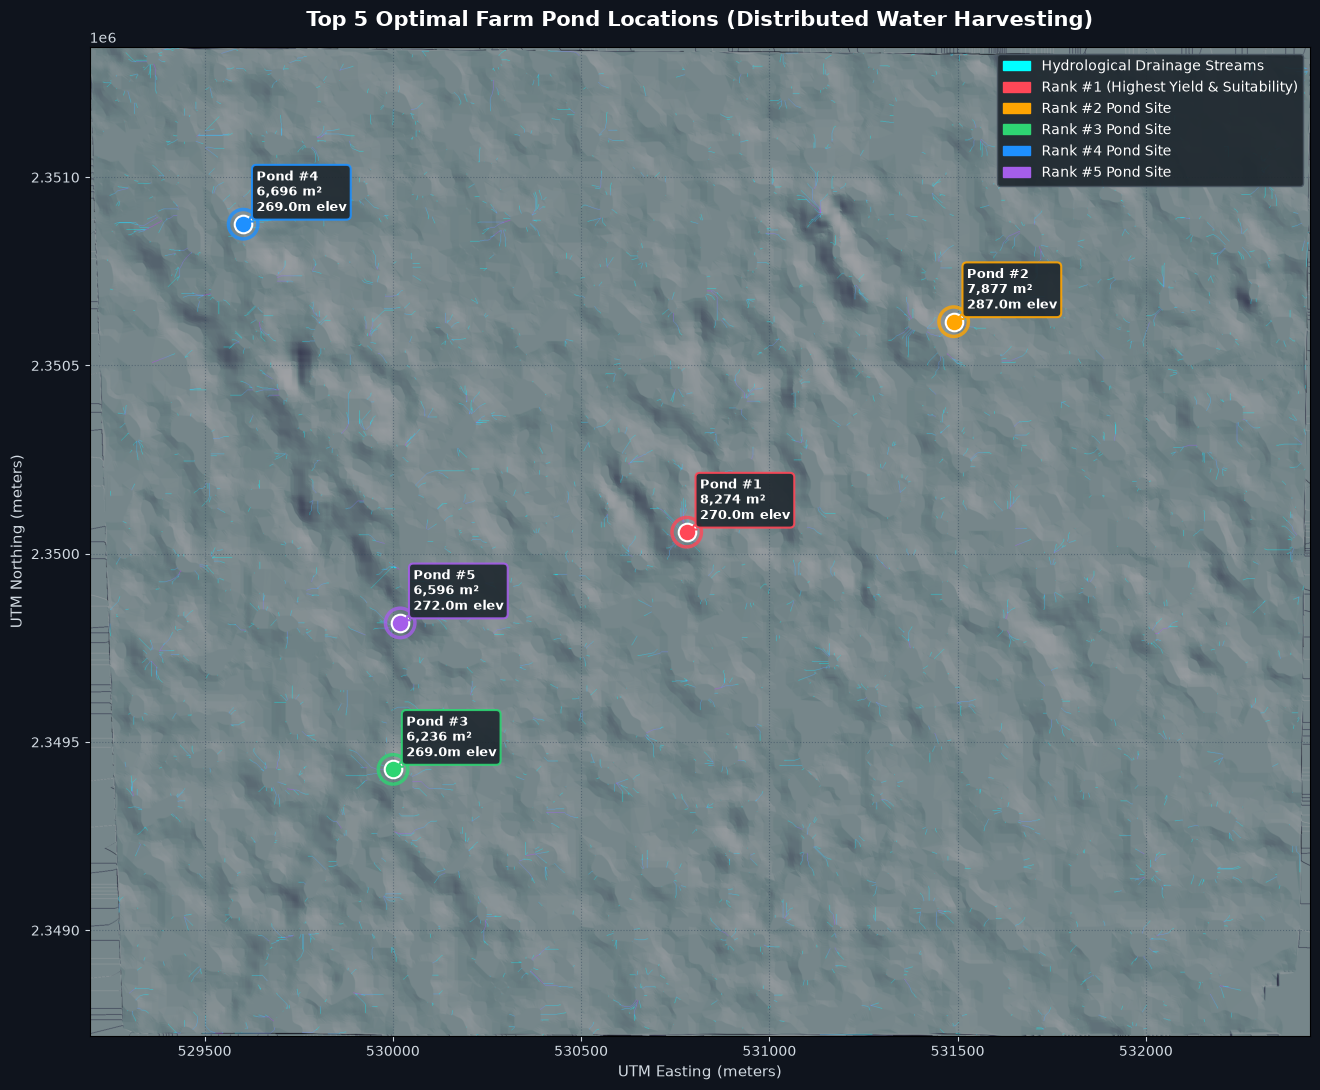

In [4]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, LogNorm
import matplotlib.patches as mpatches
from pyproj import Transformer

# --------------------------------------------------
# 1. Configuration & Input / Output Paths
# --------------------------------------------------
FLOW_FILE = "outputs/flow_accumulation.npz"
TERRAIN_FILE = "outputs/terrain_analysis.npz"
PROJ_FILE = "outputs/projected_contours.json"

OUTPUT_JSON = "outputs/top_5_pond_candidates.json"
OUTPUT_IMAGE = "outputs/top_5_ponds_visualization.png"

TOP_N = 5
MIN_SEPARATION_METERS = 150.0  # Keep ponds separated in distinct sub-catchments
MAX_SLOPE_DEGREES = 8.0        # Safe limit for earthen embankments
MIN_FLOW_CELLS = 1000.0        # Minimum catchment to fill a pond

# --------------------------------------------------
# 2. Load Hydrological & Terrain Data
# --------------------------------------------------
print(f"Loading data...")
data_flow = np.load(FLOW_FILE)
dem = data_flow["dem"]
flow_acc = data_flow["flow_accumulation"]
resolution = float(data_flow["resolution"])
grid_x = data_flow["grid_x"]
grid_y = data_flow["grid_y"]
rows, cols = dem.shape

data_terrain = np.load(TERRAIN_FILE)
slope_deg = data_terrain["slope_degrees"]

with open(PROJ_FILE, "r") as f:
    proj_meta = json.load(f)["coordinate_system"]

epsg = proj_meta["target"]
transformer_inv = Transformer.from_crs(epsg, "EPSG:4326", always_xy=True)

# --------------------------------------------------
# 3. Filter Valid Candidate Cells
# --------------------------------------------------
# Mask borders (50m buffer) and steep slopes
BORDER = int(50 / resolution)
valid_mask = np.zeros((rows, cols), dtype=bool)
valid_mask[BORDER:-BORDER, BORDER:-BORDER] = True
valid_mask &= (slope_deg <= MAX_SLOPE_DEGREES)
valid_mask &= (flow_acc >= MIN_FLOW_CELLS)

cand_r, cand_c = np.where(valid_mask)
print(f"Total candidate cells meeting criteria: {len(cand_r):,}")

# --------------------------------------------------
# 4. Multi-Criteria Suitability Scoring (AHP)
# --------------------------------------------------
c_flow = flow_acc[cand_r, cand_c]
c_slope = slope_deg[cand_r, cand_c]
c_elev = dem[cand_r, cand_c]

def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min()) if arr.max() > arr.min() else np.zeros_like(arr)

norm_flow = normalize(c_flow)
norm_slope = normalize(c_slope)
norm_elev = normalize(c_elev)

# Score formula: 60% Flow + 30% Flat Slope + 10% Low Elevation
scores = (0.60 * norm_flow) + (0.30 * (1.0 - norm_slope)) + (0.10 * (1.0 - norm_elev))

# --------------------------------------------------
# 5. Spatial Non-Maximum Suppression (Select Top 5)
# --------------------------------------------------
sorted_indices = np.argsort(scores)[::-1]
selected_ponds = []

for idx in sorted_indices:
    r, c = cand_r[idx], cand_c[idx]
    x, y = float(grid_x[r, c]), float(grid_y[r, c])
    
    # Check minimum distance separation
    too_close = False
    for prev in selected_ponds:
        dist = np.sqrt((x - prev["x_m"])**2 + (y - prev["y_m"])**2)
        if dist < MIN_SEPARATION_METERS:
            too_close = True
            break
            
    if not too_close:
        lon, lat = transformer_inv.transform(x, y)
        pond_info = {
            "rank": len(selected_ponds) + 1,
            "latitude": round(float(lat), 6),
            "longitude": round(float(lon), 6),
            "x_m": round(x, 1),
            "y_m": round(y, 1),
            "elevation_m": round(float(dem[r, c]), 1),
            "slope_deg": round(float(slope_deg[r, c]), 2),
            "flow_accumulation_m2": round(float(flow_acc[r, c]), 1),
            "suitability_score": round(float(scores[idx]), 4),
            "google_maps_url": f"https://www.google.com/maps?q={lat:.6f},{lon:.6f}"
        }
        selected_ponds.append(pond_info)
        
        if len(selected_ponds) == TOP_N:
            break

# Save to JSON
with open(OUTPUT_JSON, "w") as f:
    json.dump({"top_5_ponds": selected_ponds}, f, indent=2)

print("\n=========================================================================")
print(f" TOP {TOP_N} OPTIMAL POND LOCATIONS (Min Distance: {MIN_SEPARATION_METERS}m)")
print("=========================================================================")
for p in selected_ponds:
    print(f"[RANK #{p['rank']}] Score: {p['suitability_score']:.4f} | Elev: {p['elevation_m']}m | Slope: {p['slope_deg']}° | Catchment: {p['flow_accumulation_m2']:,.0f}m²")
    print(f"  • Lat: {p['latitude']}, Lon: {p['longitude']} (UTM X={p['x_m']}, Y={p['y_m']})")
    print(f"  • Maps: {p['google_maps_url']}")
print("=========================================================================")

# --------------------------------------------------
# 6. Generate High-Contrast Visual Map
# --------------------------------------------------
min_x, max_x = grid_x.min(), grid_x.max()
min_y, max_y = grid_y.min(), grid_y.max()
extent = [min_x, max_x, min_y, max_y]

ls = LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(dem, vert_exag=2.0, dx=resolution, dy=resolution)

plt.figure(figsize=(15, 11), facecolor="#0f141d")
ax = plt.gca()
ax.set_facecolor("#0f141d")

# Background Hillshade
ax.imshow(hillshade, origin="lower", extent=extent, cmap="bone", alpha=0.6)

# Overlay Bright Blue Drainage Streams (> 500 m²)
stream_mask = np.ma.masked_where(flow_acc < 500, flow_acc)
ax.imshow(stream_mask, origin="lower", extent=extent, cmap="cool", norm=LogNorm(vmin=500, vmax=flow_acc.max()), alpha=0.9)

# Colors for Rank Badges
rank_colors = ["#ff4757", "#ffa502", "#2ed573", "#1e90ff", "#a55eea"]

# Plot the 5 Ponds as Glowing Targets
for p in selected_ponds:
    r_idx = p["rank"] - 1
    col = rank_colors[r_idx]
    
    # Outer Pulse Ring
    ax.scatter(p["x_m"], p["y_m"], s=450, facecolors="none", edgecolors=col, linewidth=2.5, alpha=0.8, zorder=5)
    # Inner Solid Center
    ax.scatter(p["x_m"], p["y_m"], s=160, color=col, edgecolors="white", linewidth=1.5, zorder=6)
    
    # Text Annotation Badge
    label_txt = f"Pond #{p['rank']}\n{p['flow_accumulation_m2']:,.0f} m²\n{p['elevation_m']}m elev"
    ax.annotate(
        label_txt,
        xy=(p["x_m"], p["y_m"]),
        xytext=(p["x_m"] + 35, p["y_m"] + 35),
        fontsize=9,
        fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#1e272e", edgecolor=col, alpha=0.9, linewidth=1.5),
        arrowprops=dict(arrowstyle="->", color=col, lw=1.5),
        zorder=7
    )

# Legend
patches = [
    mpatches.Patch(color="#00ffff", label="Hydrological Drainage Streams"),
    mpatches.Patch(color="#ff4757", label="Rank #1 (Highest Yield & Suitability)"),
    mpatches.Patch(color="#ffa502", label="Rank #2 Pond Site"),
    mpatches.Patch(color="#2ed573", label="Rank #3 Pond Site"),
    mpatches.Patch(color="#1e90ff", label="Rank #4 Pond Site"),
    mpatches.Patch(color="#a55eea", label="Rank #5 Pond Site")
]
leg = ax.legend(handles=patches, loc="upper right", framealpha=0.92, facecolor="#1e272e", edgecolor="#485460", fontsize=10)
for text in leg.get_texts():
    text.set_color("white")

plt.title("Top 5 Optimal Farm Pond Locations (Distributed Water Harvesting)", fontsize=15, fontweight="bold", color="white", pad=15)
plt.xlabel("UTM Easting (meters)", color="#d2dae2", fontsize=11)
plt.ylabel("UTM Northing (meters)", color="#d2dae2", fontsize=11)
ax.tick_params(colors="#d2dae2")
ax.grid(True, linestyle=":", color="#34495e", alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_IMAGE, dpi=300, bbox_inches="tight", facecolor="#0f141d")
print(f"\nSaved visualization map to: {OUTPUT_IMAGE}")
print(f"Saved candidate metadata to: {OUTPUT_JSON}")
plt.show()
